In [2]:
import pandas as pd 
#Load the orders dataset

df_orders = pd.read_csv("../data/raw/olist_orders_dataset.csv")

#first look
print("Shape:",df_orders.shape)
print("\nFirst 5 rows:")
df_orders.head()

Shape: (99441, 8)

First 5 rows:


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [3]:
#column names and data types
print("Columns:")
print(df_orders.dtypes)

print("\nMissing values per column:")
print (df_orders.isnull().sum())


Columns:
order_id                         str
customer_id                      str
order_status                     str
order_purchase_timestamp         str
order_approved_at                str
order_delivered_carrier_date     str
order_delivered_customer_date    str
order_estimated_delivery_date    str
dtype: object

Missing values per column:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64


In [4]:
# Convert all date columns from text to actual datetime
date_columns = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_columns:
    df_orders[col] = pd.to_datetime(df_orders[col])

# Confirm the fix
print("Updated data types:")
print(df_orders.dtypes)

Updated data types:
order_id                                    str
customer_id                                 str
order_status                                str
order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
dtype: object


In [5]:
# Calculate delivery delay (actual vs estimated)
df_orders['delivery_delay_days'] = (
    df_orders['order_delivered_customer_date'] - 
    df_orders['order_estimated_delivery_date']
).dt.days

# Order status breakdown
print("Order Status Counts:")
print(df_orders['order_status'].value_counts())

print("\nDelivery Delay Stats (delivered orders only):")
print(df_orders['delivery_delay_days'].describe())

Order Status Counts:
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

Delivery Delay Stats (delivered orders only):
count    96476.000000
mean       -11.876881
std         10.183854
min       -147.000000
25%        -17.000000
50%        -12.000000
75%         -7.000000
max        188.000000
Name: delivery_delay_days, dtype: float64


In [6]:
# Load remaining datasets
df_items = pd.read_csv("../data/raw/olist_order_items_dataset.csv")
df_customers = pd.read_csv("../data/raw/olist_customers_dataset.csv")
df_products = pd.read_csv("../data/raw/olist_products_dataset.csv")
df_reviews = pd.read_csv("../data/raw/olist_order_reviews_dataset.csv")
df_payments = pd.read_csv("../data/raw/olist_order_payments_dataset.csv")

# Check shapes of all datasets
datasets = {
    'orders': df_orders,
    'items': df_items,
    'customers': df_customers,
    'products': df_products,
    'reviews': df_reviews,
    'payments': df_payments
}

for name, df in datasets.items():
    print(f"{name}: {df.shape}")

orders: (99441, 9)
items: (112650, 7)
customers: (99441, 5)
products: (32951, 9)
reviews: (99224, 7)
payments: (103886, 5)


In [7]:
import os 
files = os.listdir("../data/raw/")
for f in files:
    print(f)

olist_customers_dataset.csv
olist_geolocation_dataset.csv
olist_orders_dataset.csv
olist_order_items_dataset.csv
olist_order_payments_dataset.csv
olist_order_reviews_dataset.csv
olist_products_dataset.csv
olist_sellers_dataset.csv
product_category_name_translation.csv


In [8]:
# Merge orders + customers + items + payments
df_master = df_orders.merge(df_customers, on='customer_id', how='left')

df_master = df_master.merge(
    df_items,
    on='order_id',
    how='left'
)

# NEW: Merge product information
df_master = df_master.merge(
    df_products,
    on='product_id',
    how='left'
)

df_master = df_master.merge(
    df_payments,
    on='order_id',
    how='left'
)
print("Master dataframe shape:", df_master.shape)
print("\nColumns:", df_master.columns.tolist())

Master dataframe shape: (118434, 31)

Columns: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'delivery_delay_days', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value']


In [17]:
# Save master dataframe
df_master.to_csv("../data/processed/master_data.csv", index=False)

print("Master data saved successfully!")
print("File saved to: data/processed/master_data.csv")

Master data saved successfully!
File saved to: data/processed/master_data.csv


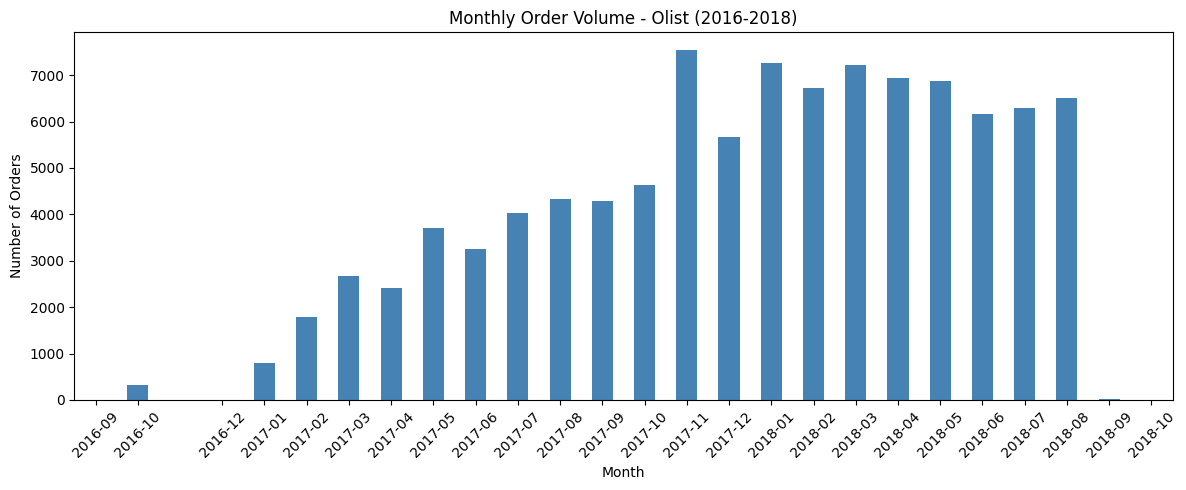

Chart saved to outputs folder!


In [10]:
import matplotlib.pyplot as plt

# Orders per month
df_orders['order_month'] = df_orders['order_purchase_timestamp'].dt.to_period('M')
monthly_orders = df_orders.groupby('order_month').size()

plt.figure(figsize=(12, 5))
monthly_orders.plot(kind='bar', color='steelblue')
plt.title('Monthly Order Volume - Olist (2016-2018)')
plt.xlabel('Month')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../outputs/monthly_orders.png')
plt.show()

print("Chart saved to outputs folder!")

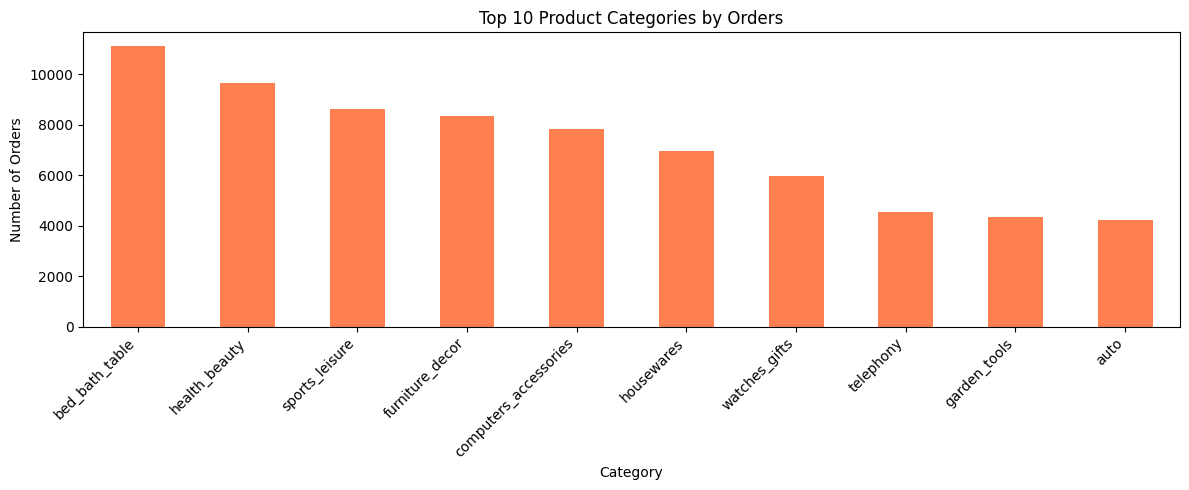

In [11]:
# Load products with category translation
df_products = pd.read_csv("../data/raw/olist_products_dataset.csv")
df_translation = pd.read_csv("../data/raw/product_category_name_translation.csv")
df_items = pd.read_csv("../data/raw/olist_order_items_dataset.csv")

# Merge to get English category names
df_products = df_products.merge(df_translation, on='product_category_name', how='left')

# Merge items with products
df_items = df_items.merge(df_products[['product_id','product_category_name_english']], 
                           on='product_id', how='left')

# Top 10 categories by order count
top_categories = df_items['product_category_name_english'].value_counts().head(10)

plt.figure(figsize=(12, 5))
top_categories.plot(kind='bar', color='coral')
plt.title('Top 10 Product Categories by Orders')
plt.xlabel('Category')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../outputs/top_categories.png')
plt.show()

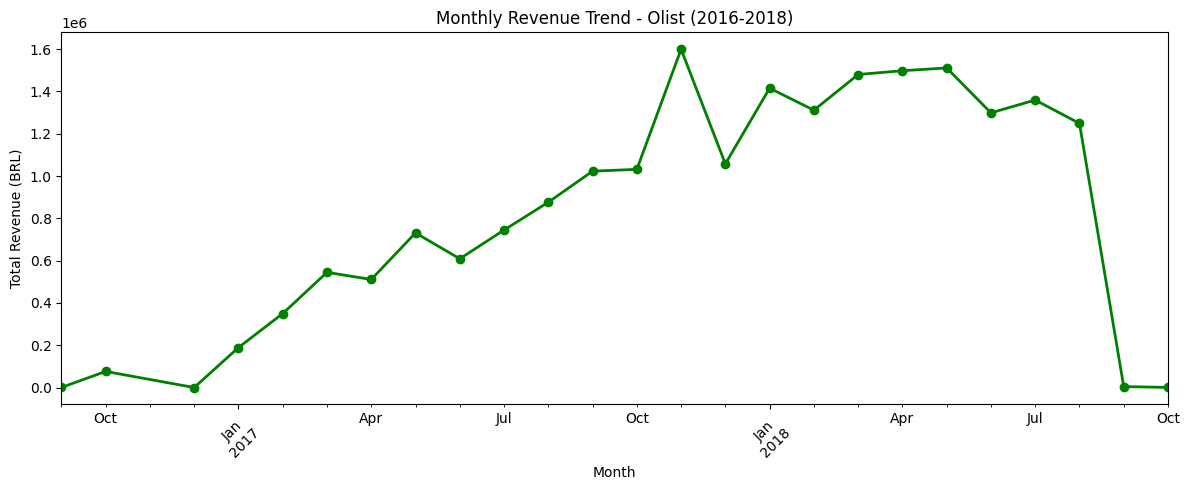

In [12]:
df_payments = pd.read_csv("../data/raw/olist_order_payments_dataset.csv")
df_master = pd.read_csv("../data/processed/master_data.csv")
df_master['order_purchase_timestamp'] = pd.to_datetime(df_master['order_purchase_timestamp'])

df_master['order_month'] = df_master['order_purchase_timestamp'].dt.to_period('M')
monthly_revenue = df_master.groupby('order_month')['payment_value'].sum()

plt.figure(figsize=(12, 5))
monthly_revenue.plot(kind='line', color='green', marker='o', linewidth=2)
plt.title('Monthly Revenue Trend - Olist (2016-2018)')
plt.xlabel('Month')
plt.ylabel('Total Revenue (BRL)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../outputs/monthly_revenue.png')
plt.show()

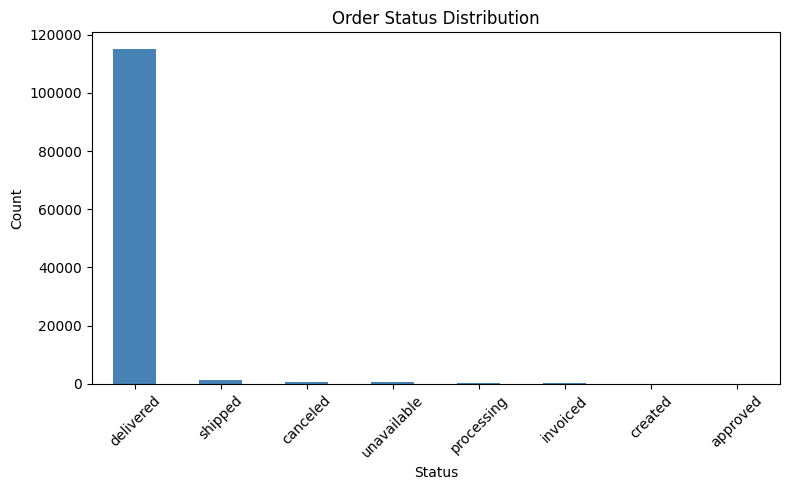

In [13]:
status_counts = df_master['order_status'].value_counts()

plt.figure(figsize=(8, 5))
status_counts.plot(kind='bar', color='steelblue')
plt.title('Order Status Distribution')
plt.xlabel('Status')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../outputs/order_status.png')
plt.show()

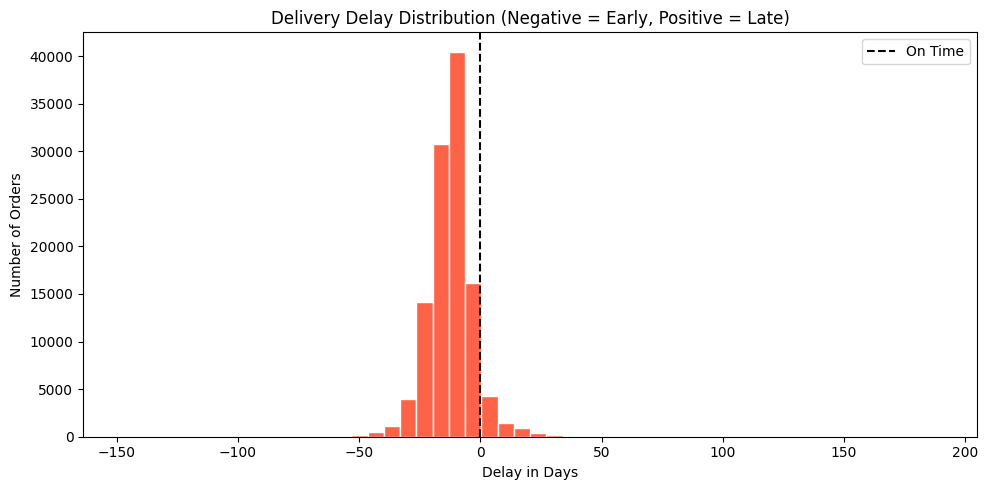

In [14]:
df_master['delivery_delay_days'] = (
    pd.to_datetime(df_master['order_delivered_customer_date']) -
    pd.to_datetime(df_master['order_estimated_delivery_date'])
).dt.days

delivered = df_master[df_master['order_status'] == 'delivered']['delivery_delay_days'].dropna()

plt.figure(figsize=(10, 5))
plt.hist(delivered, bins=50, color='tomato', edgecolor='white')
plt.title('Delivery Delay Distribution (Negative = Early, Positive = Late)')
plt.xlabel('Delay in Days')
plt.ylabel('Number of Orders')
plt.axvline(x=0, color='black', linestyle='--', label='On Time')
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/delivery_delay.png')
plt.show()

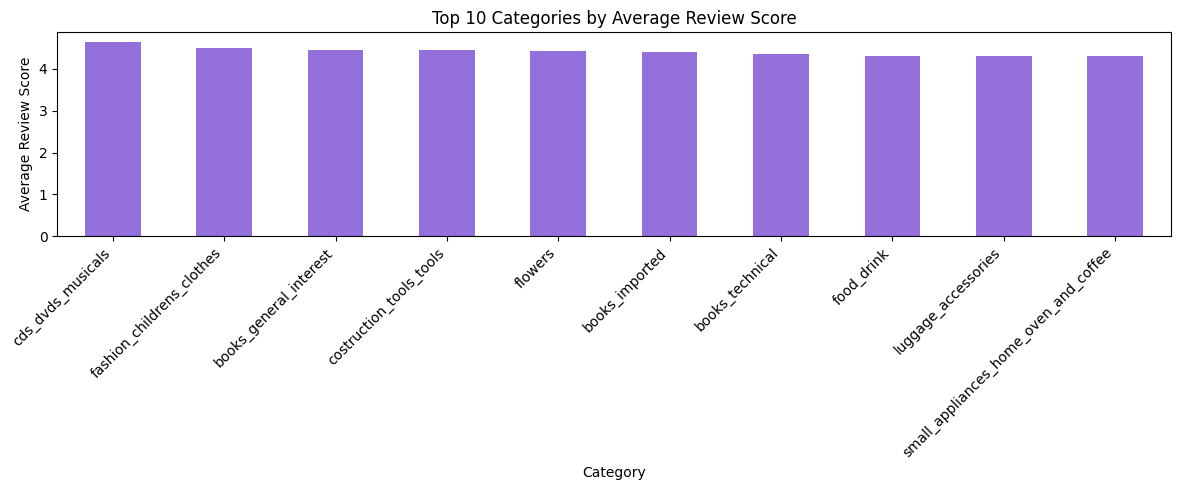

In [15]:
df_reviews = pd.read_csv("../data/raw/olist_order_reviews_dataset.csv")
df_items2 = pd.read_csv("../data/raw/olist_order_items_dataset.csv")
df_products2 = pd.read_csv("../data/raw/olist_products_dataset.csv")
df_translation2 = pd.read_csv("../data/raw/product_category_name_translation.csv")

df_products2 = df_products2.merge(df_translation2, on='product_category_name', how='left')
df_items2 = df_items2.merge(df_products2[['product_id','product_category_name_english']], on='product_id', how='left')
df_review_data = df_items2.merge(df_reviews[['order_id','review_score']], on='order_id', how='left')

avg_review = df_review_data.groupby('product_category_name_english')['review_score'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 5))
avg_review.plot(kind='bar', color='mediumpurple')
plt.title('Top 10 Categories by Average Review Score')
plt.xlabel('Category')
plt.ylabel('Average Review Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../outputs/review_scores.png')
plt.show()

In [16]:
print("=== SmartOps EDA Summary ===")
print(f"Total Orders: {df_master['order_id'].nunique():,}")
print(f"Total Revenue: R${df_master['payment_value'].sum():,.2f}")
print(f"Avg Order Value: R${df_master['payment_value'].mean():,.2f}")
print(f"Delivery Rate: {(df_master['order_status']=='delivered').mean()*100:.1f}%")
print(f"Avg Delivery Delay: {df_master['delivery_delay_days'].mean():.1f} days")
print(f"Date Range: {df_master['order_purchase_timestamp'].min()} to {df_master['order_purchase_timestamp'].max()}")
print("\nEDA Complete. All charts saved to outputs/ folder.")

=== SmartOps EDA Summary ===
Total Orders: 99,441
Total Revenue: R$20,470,726.66
Avg Order Value: R$172.85
Delivery Rate: 97.1%
Avg Delivery Delay: -12.0 days
Date Range: 2016-09-04 21:15:19 to 2018-10-17 17:30:18

EDA Complete. All charts saved to outputs/ folder.
